### Задача 3. Реализация обхода в ширину из нескольких стартовых вершин (Multiple-Source BFS)

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import os
import time

import graphblas as gb
from graphblas import Matrix, Vector, Scalar
from graphblas import dtypes
from graphblas import unary, binary, monoid, semiring
from graphblas.io import mmread

import warnings
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('bmh')
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

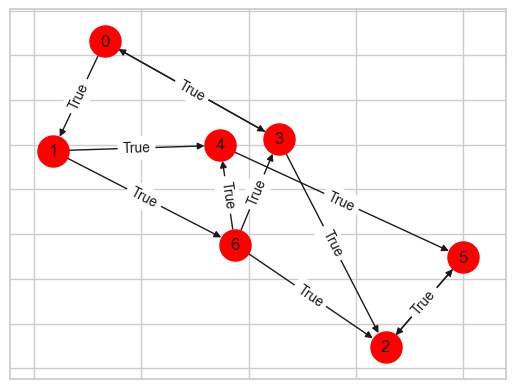

In [2]:
edges = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
]

A = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
gb.viz.draw(A)

Везде считаем, что вершины графа занумерованы подряд с нуля.

**1. Используя `python-graphblas` реализовать функцию обхода ориентированного графа (MSBFS-Levels) в ширину из нескольких заданных стартовых вершин.**

- Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.

- Функция возвращает массив пар: стартовая вершина, и массив (`levels`), где для каждой вершины указано, на каком уровне она достижима из этой стартовой. Стартовая вершина достижима на нулевом уровне, если вершина не достижима, то значение соответствующей ячейки сделайте равной -1.

In [3]:
def msbfs_levels(A, start_el, semiring=semiring.lor_land):

    n = A.nrows
    num_starts = len(start_el)

    F = Matrix(bool, num_starts, n)
    L = Matrix(int, num_starts, n)
    
    # инициализация нулевого уровня для стартовых вершин
    for i, start_v in enumerate(start_el):
        F[i, start_v] = True
        L[i, start_v] = 0
        
    level = 1
    while True:
        F(~L.S, replace=True) << F.mxm(A, semiring)

        if F.nvals == 0:
            break

        L(F.S) << level
        level += 1

    # итоговый массив пар
    results = []
    for i, start_v in enumerate(start_el):
        row_vec = L[i, :]
        dense_levels = np.full(n, -1, dtype=int)
        indices, values = row_vec.to_coo()
        dense_levels[indices] = values
        
        results.append((start_v, dense_levels))
        
    return results

In [4]:
# массив стартовых вершин
starts = [0, 1, 2, 3]

# MSBFS
msbfs_results = msbfs_levels(A, starts)

# результат
for start_node, levels in msbfs_results:
    print(f'Старт: {start_node} | Уровни: {levels}')

Старт: 0 | Уровни: [0 1 2 1 2 3 2]
Старт: 1 | Уровни: [3 0 2 2 1 2 1]
Старт: 2 | Уровни: [-1 -1  0 -1 -1  1 -1]
Старт: 3 | Уровни: [1 2 1 0 3 2 3]


**2. Используя `python-graphblas` реализовать функцию обхода ориентированного графа (MSBFS-Parents) в ширину из нескольких заданных стартовых вершин.**

- Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.

- Функция возвращает массив пар: стартовая вершина, и массив (`parents`), где для каждой вершины графа указано, из какой вершины мы пришли в эту по кратчайшему пути из стартовой вершины. При этом для самой стартовой вершины такое значение взять равное -1, а для недостижимых вершин взять равное -2. При наличии нескольких возможных значений в массивах `parents` брать наименьшее.

In [5]:
def msbfs_parents(A, start_vertices, semiring_1=semiring.min_first, semiring_2=semiring.min_second):

    n = A.nrows
    num_starts = len(start_vertices)

    P = Matrix(int, num_starts, n)
    F = Matrix(int, num_starts, n)
    
    D = Matrix.from_coo(np.arange(n), np.arange(n), np.arange(n), 
                        dtype=int, nrows=n, ncols=n)
    
    for i, start_v in enumerate(start_vertices):
        P[i, start_v] = -1  
        F[i, start_v] = start_v
        
    while True:
        F_next = F.mxm(A, semiring_1)
        
        F(~P.S, replace=True) << F_next
        
        if F.nvals == 0:
            break

        P(F.S) << F
        
        F = F.mxm(D, semiring_2).new()
        

    results = []
    for i, start_v in enumerate(start_vertices):
        dense_parents = np.full(n, -2, dtype=int)
        
        row_vec = P[i, :]
        indices, values = row_vec.to_coo()
        dense_parents[indices] = values
        
        results.append((start_v, dense_parents))
        
    return results

In [6]:
starts = [0, 1, 2, 3]
msbfs_results = msbfs_parents(A, starts)

for start_node, parents in msbfs_results:
    print(f"Старт: {start_node} | Родители: {parents}")

Старт: 0 | Родители: [-1  0  3  0  1  2  1]
Старт: 1 | Родители: [ 3 -1  6  6  1  4  1]
Старт: 2 | Родители: [-2 -2 -1 -2 -2  2 -2]
Старт: 3 | Родители: [ 3  0  3 -1  1  2  1]


**3. Добавить тесты для проверки корректности полученных реализаций.**

In [7]:
def run_tests():
    print("Запуск тестов...")
    np.random.seed(42)
    
    # 10 тестов на случайных графах разных размеров
    for test_idx in range(10):
        n = np.random.randint(10, 100)
        p = np.random.uniform(0.05, 0.3)
        
        # ориентированный граф
        G = nx.erdos_renyi_graph(n, p, directed=True)

        edges = list(G.edges())

        if not edges:
            continue

        rows, cols = zip(*edges)
        A = Matrix.from_coo(rows, cols, [True] * len(rows), nrows=n, ncols=n)
        
        # случайные стартовые вершины
        num_starts = np.random.randint(1, 5)
        starts = np.random.choice(n, num_starts, replace=False).tolist()

        levels_results = msbfs_levels(A, starts)
        parents_results = msbfs_parents(A, starts)
        
        # Проверяем каждую стартовую вершину
        for i, start_v in enumerate(starts):
            # проверка уровней (Levels)
            expected_lengths = nx.single_source_shortest_path_length(G, start_v)
            actual_levels = levels_results[i][1]
            
            for v in range(n):
                if v in expected_lengths:
                    assert actual_levels[v] == expected_lengths[v], f"Ошибка в уровнях: старт {start_v}, вершина {v}"
                else:
                    assert actual_levels[v] == -1, f"Ошибка: вершина {v} должна быть недостижима из {start_v}"
            
            # проверка родителей (Parents)
            actual_parents = parents_results[i][1]
            for v in range(n):
                parent = actual_parents[v]
                if v == start_v:
                    assert parent == -1, "Родитель стартовой вершины должен быть -1"
                elif v in expected_lengths:
                    # вершина достижима. Проверяем, что родитель корректный
                    assert parent != -2, f"Вершина {v} достижима, но родитель -2"
                    assert G.has_edge(parent, v), f"Нет ребра между найденным родителем {parent} и {v}"
                    # уровень родителя должен быть ровно на 1 меньше уровня вершины
                    assert expected_lengths[parent] == expected_lengths[v] - 1
                else:
                    assert parent == -2, f"Вершина {v} недостижима, родитель должен быть -2"

    print("Все тесты успешно пройдены!")

# Запуск
run_tests()

Запуск тестов...
Все тесты успешно пройдены!


**4. Провести экспериментальное исследование полученных реализаций на некоторых больших графах в формате `Matrix Market` с сайта SuiteSparse Matrix Collection и на случайных сгенерированных. При этом описать зависимость времени работы всех полученных реализаций от размеров графа, его степени разреженности, количестве стартовых вершин.**

In [8]:
os.listdir('./data')

['bcspwr10.mtx',
 'bcsstk30.mtx',
 'bcsstk33.mtx',
 'dwt_992.mtx',
 'gearbox.mtx',
 'pct20stif.mtx',
 'pli.mtx',
 'troll.mtx']

In [9]:
def run_experiments():
    results = []
    
    # тестирование на реальных графах Matrix Market
    data_dir = './data'

    for filename in os.listdir(data_dir):
        filepath = os.path.join(data_dir, filename)
        A = mmread(filepath)
        
        # булевой тип для работы MSBFS-Levels
        A = A.dup(dtype=bool)
        n = A.nrows
        nnz = A.nvals
        density = nnz / (n * n) if n > 0 else 0
        
        for k in [1, 10, 50, 100]:
            if k > n: continue
            starts = np.random.choice(n, k, replace=False).tolist()
            
            t_start = time.perf_counter()
            msbfs_levels(A, starts)
            t_levels = time.perf_counter() - t_start
            
            t_start = time.perf_counter()
            msbfs_parents(A, starts)
            t_parents = time.perf_counter() - t_start
            
            results.append({
                'Graph': filename, 'N': n, 'Edges': nnz, 'Density': density,
                'Num_Starts (K)': k, 'Time_Levels (s)': t_levels, 'Time_Parents (s)': t_parents
            })

    # тестирование на сгенерированных графах (влияние размера и плотности)
    sizes = [1000, 5000, 10000]
    densities = [0.001, 0.01, 0.05, 0.1]
    k_starts = [10, 50]
    
    for n in sizes:
        for p in densities:
            # генерация случайного разреженного графа
            G = nx.fast_gnp_random_graph(n, p, directed=True)
            edges = list(G.edges())
            if not edges: continue
            rows, cols = zip(*edges)
            A = Matrix.from_coo(rows, cols, [True]*len(rows), nrows=n, ncols=n)
            
            for k in k_starts:
                starts = np.random.choice(n, k, replace=False).tolist()
                
                # замер Levels
                t0 = time.perf_counter()
                msbfs_levels(A, starts)
                t_levels = time.perf_counter() - t0
                
                # замер Parents
                t0 = time.perf_counter()
                msbfs_parents(A, starts)
                t_parents = time.perf_counter() - t0
                
                results.append({
                    'Graph': f'Random_N{n}_p{p}', 'N': n, 'Edges': len(edges), 'Density': p,
                    'Num_Starts (K)': k, 'Time_Levels (s)': t_levels, 'Time_Parents (s)': t_parents
                })
                
    df_results = pd.DataFrame(results)
    return df_results

In [10]:
df = run_experiments()
df

,Graph,N,Edges,Density,Num_Starts (K),Time_Levels (s),Time_Parents (s)
0,bcspwr10.mtx,5300,21842,0.000778,1,0.008024,0.012697
1,bcspwr10.mtx,5300,21842,0.000778,10,0.031660,0.025414
2,bcspwr10.mtx,5300,21842,0.000778,50,0.042118,0.038808
3,bcspwr10.mtx,5300,21842,0.000778,100,0.068173,0.083078
4,bcsstk30.mtx,28924,2043492,0.002443,1,0.011205,0.013916
5,bcsstk30.mtx,28924,2043492,0.002443,10,0.108253,0.122072
6,bcsstk30.mtx,28924,2043492,0.002443,50,0.398753,0.320526
7,bcsstk30.mtx,28924,2043492,0.002443,100,0.644540,0.509185
8,bcsstk33.mtx,8738,591904,0.007752,1,0.006222,0.005685
9,bcsstk33.mtx,8738,591904,0.007752,10,0.025067,0.026649


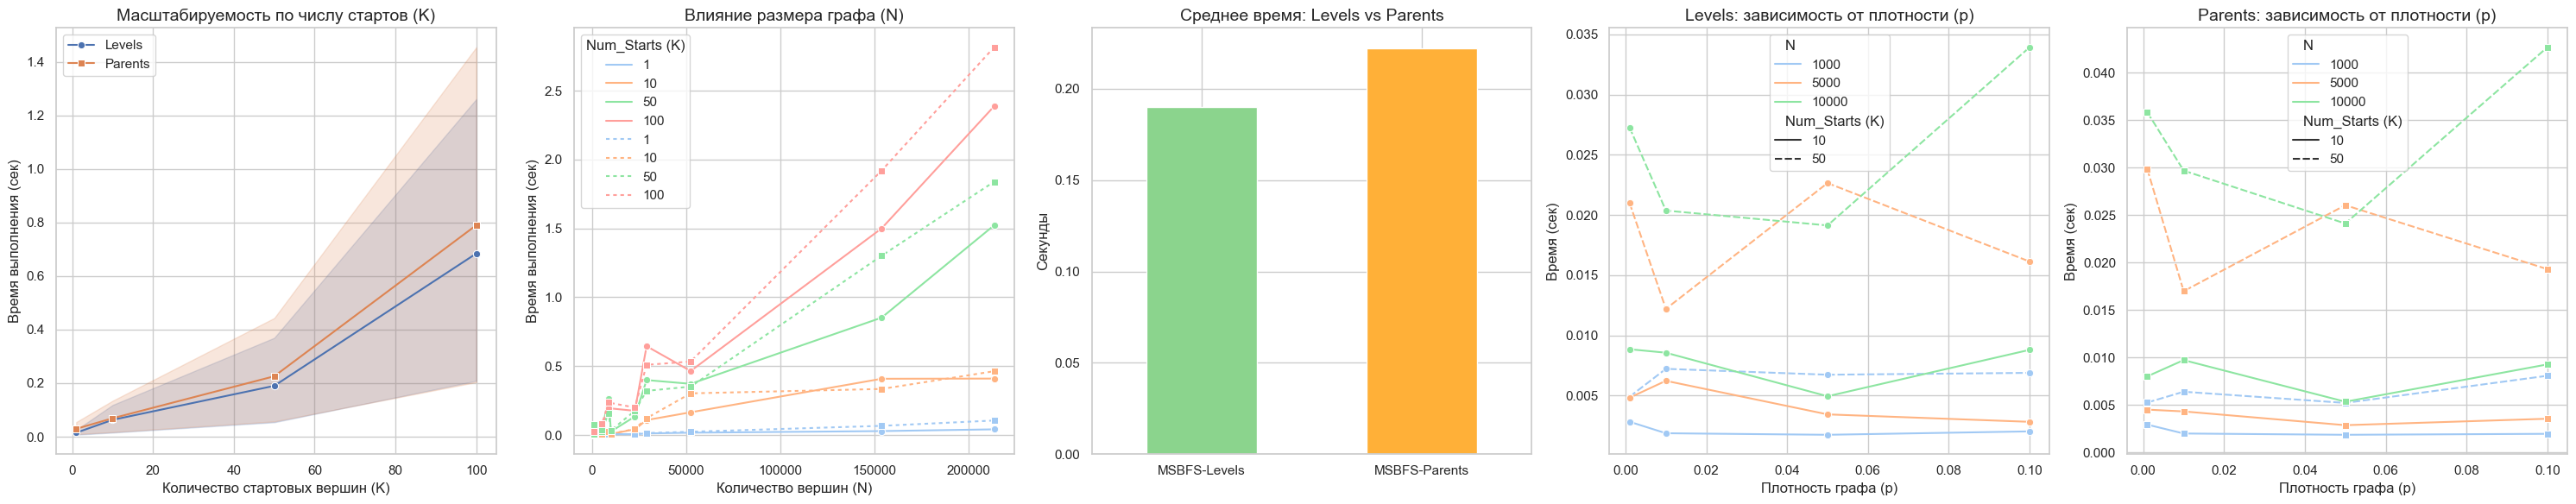

In [11]:
def plot_experimental_results(df):

    fig, axes = plt.subplots(1, 5, figsize=(30, 6))

    # зависимость времени от количества стартовых вершин (K)
    sns.lineplot(ax=axes[0], data=df, x='Num_Starts (K)', y='Time_Levels (s)', marker='o', label='Levels', palette='pastel')
    sns.lineplot(ax=axes[0], data=df, x='Num_Starts (K)', y='Time_Parents (s)', marker='s', label='Parents', palette='pastel')
    axes[0].set_title('Масштабируемость по числу стартов (K)', fontsize=14)
    axes[0].set_ylabel('Время выполнения (сек)')
    axes[0].set_xlabel('Количество стартовых вершин (K)')

    # зависимость времени от размера графа (N)
    sns.lineplot(ax=axes[1], data=df, x='N', y='Time_Levels (s)', hue='Num_Starts (K)', marker='o', palette='pastel')
    sns.lineplot(ax=axes[1], data=df, x='N', y='Time_Parents (s)', hue='Num_Starts (K)', marker='s',
                 dashes=[(2, 2)] * df['Num_Starts (K)'].nunique(), style='Num_Starts (K)', palette='pastel')
    axes[1].set_title('Влияние размера графа (N)', fontsize=14)
    axes[1].set_ylabel('Время выполнения (сек)')
    axes[1].set_xlabel('Количество вершин (N)')

    # Levels vs Parents (среднее)
    avg_times = df[['Time_Levels (s)', 'Time_Parents (s)']].mean()
    avg_times.plot(kind='bar', ax=axes[2], rot=0, color=["#8BD48D", "#FFB038"])
    axes[2].set_title('Среднее время: Levels vs Parents', fontsize=14)
    axes[2].set_ylabel('Секунды')
    axes[2].set_xticklabels(['MSBFS-Levels', 'MSBFS-Parents'])

    df_random = df[df['Graph'].str.contains('Random')]

    # зависимость Levels от плотности
    sns.lineplot(ax=axes[3], data=df_random, x='Density', y='Time_Levels (s)', hue='N', style='Num_Starts (K)', marker='o', palette='pastel')
    axes[3].set_title('Levels: зависимость от плотности (p)', fontsize=14)
    axes[3].set_xlabel('Плотность графа (p)')
    axes[3].set_ylabel('Время (сек)')

    # зависимость Parents от плотности
    sns.lineplot(ax=axes[4], data=df_random, x='Density', y='Time_Parents (s)', hue='N', style='Num_Starts (K)', marker='s', palette='pastel')
    axes[4].set_title('Parents: зависимость от плотности (p)', fontsize=14)
    axes[4].set_xlabel('Плотность графа (p)')
    axes[4].set_ylabel('Время (сек)')

    plt.tight_layout()
    plt.show()


plot_experimental_results(df)

Из проведённых экспериментов можно сделать вывод, что:

- алгоритм msbfs_levels работает быстрее алгоритма msbfs_parents

**5. Добавить реализации описанных алгоритмов с использованием других полуколец (`any.pair` для `levels` и `any.first` для `parents`). Добавить тесты для проверки корректности. Провести экспериментальное исследование со сравнением этих реализаций с первоначальными на различных графах.**

In [12]:
def test_any_implementations():
    n = np.random.randint(10, 100)
    p = np.random.uniform(0.05, 0.3)
    
    # ориентированный граф
    G = nx.erdos_renyi_graph(n, p, directed=True)
    
    edges = list(G.edges())

    rows, cols = zip(*edges)
    A = Matrix.from_coo(rows, cols, [True] * len(rows), nrows=n, ncols=n)
    
    # случайные стартовые вершины
    num_starts = np.random.randint(1, 5)
    starts = np.random.choice(n, num_starts, replace=False).tolist()
    
    levels_any = msbfs_levels(A, starts, semiring=semiring.any_pair)
    parents_any = msbfs_parents(A, starts, semiring_1=semiring.any_first, semiring_2=semiring.any_second)
    
    for i, start_v in enumerate(starts):
        actual_parents = parents_any[i][1]
        dist = nx.single_source_shortest_path_length(G, start_v)
        for v, p in enumerate(actual_parents):
            if v == start_v: assert p == -1
            elif v in dist:
                assert G.has_edge(p, v) # родитель должен иметь ребро к вершине
                assert dist[p] == dist[v] - 1 # быть на уровень выше
    print("Тесты пройдены!")

test_any_implementations()

Тесты пройдены!


In [13]:
def time_func(func, *args):
    t0 = time.perf_counter()
    func(*args)
    return time.perf_counter() - t0


def run_experiments_extended():
    results = []
    
    # конфигурация тестов
    k_values = [1, 10, 50, 100]
    random_sizes = [1000, 5000, 10000]
    random_densities = [0.001, 0.01, 0.05, 0.1]
    
    # Matrix Market
    data_dir = './data'
    if os.path.exists(data_dir):
        for filename in os.listdir(data_dir):
            if not filename.endswith('.mtx'): continue
            
            A = mmread(os.path.join(data_dir, filename))
            A_bool = A.dup(dtype=bool) # Для уровней
            n = A.nrows
            nnz = A.nvals
            density = nnz / (n * n) if n > 0 else 0

            for k in k_values:
                if k > n: continue
                starts = np.random.choice(n, k, replace=False).tolist()
                
                t_lv_orig = time_func(msbfs_levels, A_bool, starts)
                t_lv_any  = time_func(msbfs_levels, A_bool, starts, semiring.any_pair)
                t_pr_orig = time_func(msbfs_parents, A, starts)
                t_pr_any  = time_func(msbfs_parents, A, starts, semiring.any_first, semiring.any_second)
                
                results.append({
                    'Graph': filename, 'N': n, 'Edges': nnz, 'Density': density, 'K': k,
                    'Levels_Standard': t_lv_orig, 'Levels_Any': t_lv_any,
                    'Parents_Standard': t_pr_orig, 'Parents_Any': t_pr_any
                })

    # случайные графы
    for n in random_sizes:
        for p in random_densities:
            G = nx.fast_gnp_random_graph(n, p, directed=True)
            if G.number_of_edges() == 0: continue
            
            rows, cols = zip(*G.edges())
            A = Matrix.from_coo(rows, cols, [True]*len(rows), nrows=n, ncols=n)
            A_bool = A.dup(dtype=bool)
            nnz = A.nvals
            density = nnz / (n * n)
            
            for k in [10, 50]: 
                starts = np.random.choice(n, k, replace=False).tolist()
                
                t_lv_orig = time_func(msbfs_levels, A_bool, starts)
                t_lv_any  = time_func(msbfs_levels, A_bool, starts, semiring.any_pair)
                t_pr_orig = time_func(msbfs_parents, A, starts)
                t_pr_any  = time_func(msbfs_parents, A, starts, semiring.any_first, semiring.any_second)
                
                results.append({
                    'Graph': f'Random_N{n}_p{p}', 'N': n, 'Edges': nnz, 'Density': density, 'K': k,
                    'Levels_Standard': t_lv_orig, 'Levels_Any': t_lv_any,
                    'Parents_Standard': t_pr_orig, 'Parents_Any': t_pr_any
                })
                
    return pd.DataFrame(results)


df_res = run_experiments_extended()
df_res

,Graph,N,Edges,Density,K,Levels_Standard,Levels_Any,Parents_Standard,Parents_Any
0,bcspwr10.mtx,5300,21842,0.000778,1,0.002359,0.002008,0.003239,0.003305
1,bcspwr10.mtx,5300,21842,0.000778,10,0.009771,0.009496,0.011786,0.011569
2,bcspwr10.mtx,5300,21842,0.000778,50,0.036431,0.034175,0.040630,0.036695
3,bcspwr10.mtx,5300,21842,0.000778,100,0.064796,0.069459,0.076663,0.074925
4,bcsstk30.mtx,28924,2043492,0.002443,1,0.007337,0.006031,0.011766,0.010402
5,bcsstk30.mtx,28924,2043492,0.002443,10,0.081044,0.076571,0.103618,0.103002
6,bcsstk30.mtx,28924,2043492,0.002443,50,0.197273,0.190927,0.242482,0.241987
7,bcsstk30.mtx,28924,2043492,0.002443,100,0.283433,0.286125,0.376009,0.357972
8,bcsstk33.mtx,8738,591904,0.007752,1,0.004054,0.002531,0.004918,0.026861
9,bcsstk33.mtx,8738,591904,0.007752,10,0.014290,0.013222,0.022028,0.021878


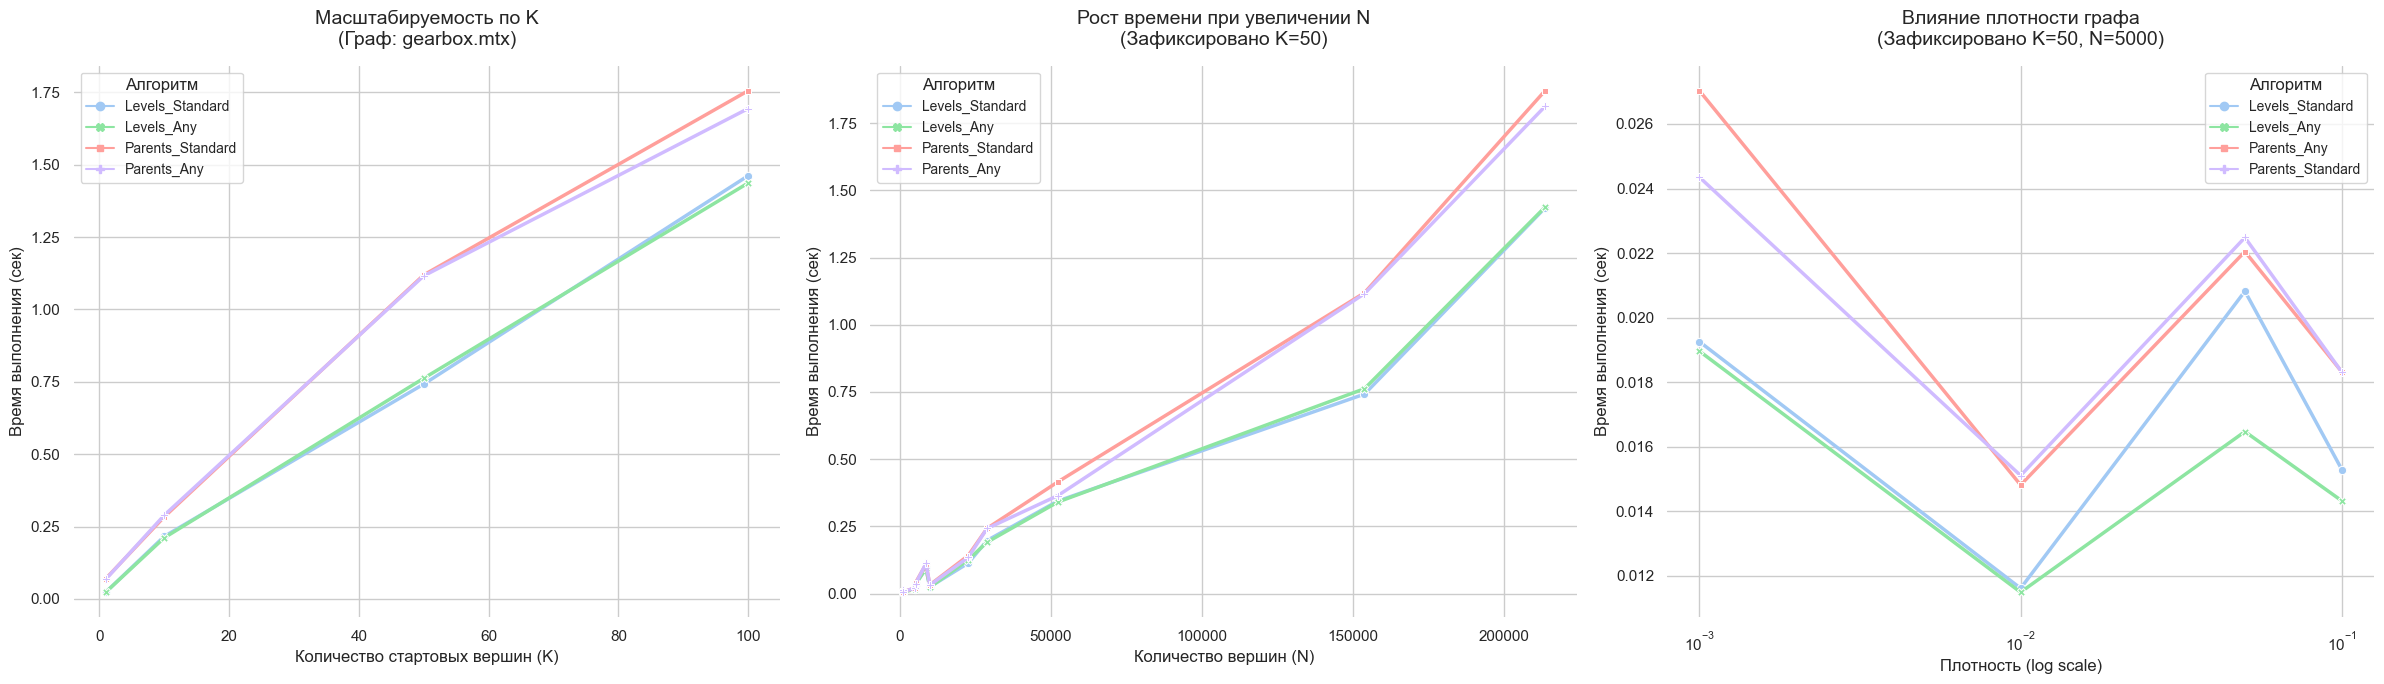

In [17]:
def plot_any_comparison(df):

    pastel_colors = ["#A1C9F4", "#8DE5A1", "#FF9F9B", "#D0BBFF"] 

    df_melted = df.melt(
        id_vars=['Graph', 'N', 'Edges', 'Density', 'K'], 
        value_vars=['Levels_Standard', 'Levels_Any', 'Parents_Standard', 'Parents_Any'],
        var_name='Algorithm', 
        value_name='Time (s)'
    )

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    # зависимость от K 
    unique_graphs = df['Graph'].unique()
    sample_graph = unique_graphs[min(4, len(unique_graphs)-1)]
    df_k = df_melted[df_melted['Graph'] == sample_graph]
    
    sns.lineplot(
        ax=axes[0], data=df_k, x='K', y='Time (s)', 
        hue='Algorithm', style='Algorithm', 
        markers=True, dashes=False, palette=pastel_colors, linewidth=2.5
    )
    axes[0].set_title(f'Масштабируемость по K\n(Граф: {sample_graph})', fontsize=14, pad=15)
    axes[0].set_xlabel('Количество стартовых вершин (K)', fontsize=12)

    # зависимость от N 
    df_n = df_melted[df_melted['K'] == 50]
    
    sns.lineplot(
        ax=axes[1], data=df_n, x='N', y='Time (s)', 
        hue='Algorithm', style='Algorithm', 
        markers=True, dashes=False, palette=pastel_colors, linewidth=2.5
    )
    axes[1].set_title('Рост времени при увеличении N\n(Зафиксировано K=50)', fontsize=14, pad=15)
    axes[1].set_xlabel('Количество вершин (N)', fontsize=12)

    # зависимость от Density 
    df_dens = df_melted[(df_melted['K'] == 50) & (df_melted['N'] == 5000)].sort_values('Density')
    
    sns.lineplot(
        ax=axes[2], data=df_dens, x='Density', y='Time (s)', 
        hue='Algorithm', style='Algorithm', 
        markers=True, dashes=False, palette=pastel_colors, linewidth=2.5
    )
    axes[2].set_title('Влияние плотности графа\n(Зафиксировано K=50, N=5000)', fontsize=14, pad=15)
    axes[2].set_xlabel('Плотность (log scale)', fontsize=12)
    axes[2].set_xscale('log') # Логарифмическая шкала для плотности

    # Общая косметика для всех осей
    for ax in axes:
        ax.set_ylabel('Время выполнения (сек)', fontsize=12)
        ax.legend(title='Алгоритм', frameon=True, facecolor='white', fontsize=10)
        sns.despine(ax=ax, left=True, bottom=True)

    plt.tight_layout()
    plt.show()


plot_any_comparison(df_res)

Можно увидеть, что:

- MSBFS-Levels: реализации `lor_land` и `any_pair` дают практически идентичные результаты производительности (всё же для производительности предпочтительнее `any_pair`, так как логическое ИЛИ (`lor`) требует чуть больше тактов, чем игнорирование значения `pair`).

- MSBFS-Parents: реализация `any_first` работает быстрее `min_first`, но не гарантирует выбор родителя с наименьшим индексом. Она подходит, когда допустим недетерминированный выбор одного из кратчайших путей. Использование недетерминированных полуколец (`any`) является предпочтительным для высокопроизводительных систем, если не требуется выбор строго определенного родителя (например, с наименьшим ID). Это значительно снижает нагрузку на подсистему памяти и уменьшает количество инструкций процессора.